<a href="https://colab.research.google.com/github/jmadbad/big-mac-data/blob/master/TPMDOM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# =========================
# 0) Subir CSV desde tu compu (Colab)
# =========================
from google.colab import files
import io
import pandas as pd
import numpy as np

uploaded = files.upload()
filename = list(uploaded.keys())[0]
print("Archivo cargado:", filename)

raw_text = uploaded[filename].decode("utf-8", errors="replace")
sep = "\t" if "\t" in raw_text.splitlines()[0] else (";" if ";" in raw_text.splitlines()[0] else ",")
print("Separador detectado:", repr(sep))

df = pd.read_csv(io.StringIO(raw_text), sep=sep)

# --- Parse date SIN destruirla ---
date_raw = df["date"].copy()

# Convertir coma decimal a float en TODAS las columnas EXCEPTO 'date'
def to_float_commas(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int,float,np.number)): return float(x)
    s = str(x).strip().replace(" ", "").replace("%","")
    s = s.replace(",", ".")
    try:
        return float(s)
    except:
        return np.nan

for c in df.columns:
    if c != "date":
        df[c] = df[c].apply(to_float_commas)

# Date: si viene como serial de Excel (número grande), convertir; si no, parsear DD/MM/YYYY
try:
    date_num = pd.to_numeric(date_raw, errors="coerce")
    if np.nanmean(date_num.values) > 20000:
        df["date"] = pd.to_datetime(date_num, unit="D", origin="1899-12-30")
    else:
        # Assuming DD/MM/YYYY format if not Excel serial
        df["date"] = pd.to_datetime(date_raw.astype(str), format="%d/%m/%Y", errors="coerce")
except Exception:
    # Fallback for unexpected formats, though format="%d/%m/%Y" with errors="coerce" is robust
    df["date"] = pd.to_datetime(date_raw, errors="coerce")

df = df.sort_values("date").reset_index(drop=True)

# NEW CODE: Aggregate to monthly frequency after initial parsing
# This ensures all subsequent steps work with consistent monthly data
df['date'] = pd.to_datetime(df['date']) # Ensure 'date' is datetime type

# Create a monthly period column to group by
df['month_start_date'] = df['date'].dt.to_period('M').dt.to_timestamp()

# Identify numeric columns for aggregation (excluding any potential original 'date' numeric values)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'date' in numeric_cols:
    numeric_cols.remove('date')

# Aggregate to monthly frequency by taking the mean of numeric columns
df_monthly = df.groupby('month_start_date')[numeric_cols].mean().reset_index()

# Rename 'month_start_date' back to 'date' for consistency with the rest of the notebook
df_monthly = df_monthly.rename(columns={'month_start_date': 'date'})

# Overwrite the original df with the monthly aggregated one
df = df_monthly.sort_values('date').reset_index(drop=True)

df.head()

Saving data.csv to data (1).csv
Archivo cargado: data (1).csv
Separador detectado: ';'


/tmp/ipython-input-175/839622092.py:40: RuntimeWarning: Mean of empty slice
  if np.nanmean(date_num.values) > 20000:


,date,tpm_rd,ipc_yoy,ipc_mom_sa,core_ipc_yoy,imae_yoy,imae_sa_level,fx,policy_us,oil,credit_yoy,m2_yoy,expect_inf_12m
0,2014-01-01,6.25,2.82,0.23,3.43,8.34,76.80,42.97,0.07,108.12,15.25,9.88,4.60
1,2014-02-01,6.25,2.84,0.34,3.25,5.23,75.57,43.18,0.07,108.90,16.61,10.69,4.65
2,2014-03-01,6.25,2.99,0.52,3.21,8.48,76.82,43.22,0.08,107.48,19.20,11.10,4.50
3,2014-04-01,6.25,3.49,0.43,3.39,6.35,76.91,43.20,0.09,107.76,17.42,11.29,4.58
4,2014-05-01,6.25,3.70,0.02,3.39,7.40,78.12,43.28,0.09,109.54,12.99,10.42,4.47


In [2]:
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from statistics import NormalDist

# =========================
# 1) Transformaciones y rezagos
# =========================
df["d_fx"]  = 100*np.log(df["fx"]).diff()
df["d_oil"] = 100*np.log(df["oil"]).diff()

base_exog = ["ipc_yoy","core_ipc_yoy","imae_yoy","policy_us","credit_yoy","m2_yoy","expect_inf_12m","d_fx","d_oil"]
for c in base_exog:
    df[c+"_l1"] = df[c].shift(1)

X_cols = ["ipc_yoy_l1","core_ipc_yoy_l1","imae_yoy_l1","d_fx_l1","policy_us_l1","d_oil_l1",
          "credit_yoy_l1","m2_yoy_l1","expect_inf_12m_l1"]

dfe = df[["date","tpm_rd"] + X_cols].dropna().reset_index(drop=True)
y_full = dfe["tpm_rd"].astype(float)
X_full = dfe[X_cols].astype(float)
dates  = dfe["date"]

# =========================
# 2) Modelos
# =========================
def fit_sarimax(y, X):
    m = SARIMAX(
        y, exog=X,
        order=(1,0,0),
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    # optimizador más estable + más iteraciones
    return m.fit(disp=False, method="powell", maxiter=500)

def fit_ardl_ols(y, X):
    y_l1 = y.shift(1)
    dfm = pd.concat([y, y_l1, X], axis=1).dropna()
    y2 = dfm.iloc[:,0]
    X2 = dfm.iloc[:,1:]
    X2.columns = ["tpm_l1"] + list(X.columns)
    X2 = sm.add_constant(X2, has_constant="add")
    return sm.OLS(y2, X2).fit()

def build_markov(series):
    dy = series.diff()
    states = np.where(dy>0, "up", np.where(dy<0, "down", "hold"))
    s_prev = pd.Series(states).shift(1)
    s_cur  = pd.Series(states)
    trans = pd.crosstab(s_prev, s_cur).reindex(index=["down","hold","up"], columns=["down","hold","up"], fill_value=0)
    P = trans.div(trans.sum(axis=1).replace(0, np.nan), axis=0).fillna(1/3).values
    mu = np.array([float(dy[dy<0].mean()) if (dy<0).any() else -0.25,
                   0.0,
                   float(dy[dy>0].mean()) if (dy>0).any() else 0.25])
    return P, mu, states

# =========================
# 3) Backtest (1 paso adelante)
# =========================
min_train = 24
pred = pd.DataFrame({"date": dates, "actual": y_full})
for c in ["rw","sarimax","ardl","markov"]:
    pred[c] = np.nan

for t in range(min_train, len(dfe)):
    y_tr = y_full.iloc[:t]
    X_tr = X_full.iloc[:t]

    # SARIMAX
    r1 = fit_sarimax(y_tr, X_tr)
    pred.loc[t, "sarimax"] = float(r1.get_forecast(steps=1, exog=X_full.iloc[t:t+1]).predicted_mean.iloc[0])

    # ARDL
    r2 = fit_ardl_ols(y_tr, X_tr)
    y_l1 = float(y_full.iloc[t-1])
    x_row = X_full.iloc[t].values
    Xf = pd.DataFrame([[y_l1] + list(x_row)], columns=["tpm_l1"] + X_cols)
    Xf = sm.add_constant(Xf, has_constant="add")
    Xf = Xf[r2.params.index]
    pred.loc[t, "ardl"] = float(r2.predict(Xf).iloc[0])

    # Markov
    P, mu, states = build_markov(y_tr)
    last_state = states[t-1]
    p0 = np.array([1,0,0]) if last_state=="down" else (np.array([0,1,0]) if last_state=="hold" else np.array([0,0,1]))
    p1 = p0 @ P
    exp_delta = float(p1 @ mu)
    pred.loc[t, "markov"] = float(y_full.iloc[t-1] + exp_delta)

    # Random walk
    pred.loc[t, "rw"] = float(y_full.iloc[t-1])

def metric(col):
    dfm = pred.loc[min_train:, ["actual", col]].dropna()
    e = dfm["actual"] - dfm[col]
    rmse = float(np.sqrt(np.mean(e**2)))
    mae  = float(np.mean(np.abs(e)))
    n    = int(len(dfm))
    return rmse, mae, n

metrics_out = pd.DataFrame([
    ["Benchmark: random walk", *metric("rw")],
    ["SARIMAX AR(1)+X", *metric("sarimax")],
    ["ARDL(1)+X", *metric("ardl")],
    ["Markov (cambios discretos)", *metric("markov")],
], columns=["Modelo","RMSE_pp","MAE_pp","N_oos"])
metrics_out["RMSE_pb"] = (metrics_out["RMSE_pp"]*100).round(1)
metrics_out["MAE_pb"]  = (metrics_out["MAE_pp"]*100).round(1)
metrics_out[["Modelo","RMSE_pb","MAE_pb","N_oos"]]

,Modelo,RMSE_pb,MAE_pb,N_oos
0,Benchmark: random walk,24.1,10.7,119
1,SARIMAX AR(1)+X,23.5,14.8,119
2,ARDL(1)+X,23.9,16.8,119
3,Markov (cambios discretos),23.2,11.1,119


In [23]:
# =========================
# 4) Ensamble RMSE-min (w>=0, sum(w)=1)
# =========================
oos = pred.loc[min_train:, ["actual","sarimax","ardl","markov"]].dropna()
Y = oos["actual"].values
F = oos[["sarimax","ardl","markov"]].values

def mse_w(w):
    return np.mean((Y - F@w)**2)

w0 = np.array([1/3,1/3,1/3])
cons = [{"type":"eq", "fun": lambda w: np.sum(w)-1.0}]
bnds = [(0.0,1.0)]*3
opt = minimize(mse_w, w0, method="SLSQP", bounds=bnds, constraints=cons)

w = opt.x
w = np.clip(w, 0, 1)
w = w / w.sum()

print("Pesos ensamble (RMSE-min):", w)

pred["ensamble"] = np.nan
pred.loc[min_train:, "ensamble"] = pred.loc[min_train:, ["sarimax","ardl","markov"]].values @ w

rmse_ens, mae_ens, n_ens = metric("ensamble")
print("Ensamble RMSE (pb):", round(rmse_ens*100,1), "| MAE (pb):", round(mae_ens*100,1), "| N:", n_ens)

# =========================
# 5) Pronóstico h meses (usando exógenas FUTURAS del CSV y extrapolando si es necesario)
# =========================

# Última fecha con TPM observada (histórico)
last_obs_date = df.loc[df["tpm_rd"].notna(), "date"].max()
print("Última TPM observada:", last_obs_date)

# Define the start and end of the full forecast period
start_forecast_period = last_obs_date + pd.offsets.MonthBegin(1)
end_forecast_period = pd.to_datetime('2027-12-01')

# Generate all monthly dates for the forecast period
forecast_months_full_range = pd.date_range(start=start_forecast_period, end=end_forecast_period, freq='MS')
h = len(forecast_months_full_range) # This will be 23 (Feb 2026 to Dec 2027)

# Create a DataFrame for the full extended period (historical + forecast dates)
# Start with the original df (up to the last date present in it)
df_full_extended_dates = pd.DataFrame({'date': pd.date_range(start=df['date'].min(), end=end_forecast_period, freq='MS')})

# Merge original data (df) into this full date range
df_temp = pd.merge(df_full_extended_dates, df, on='date', how='left')

# Identify exogenous variables that need to be filled/extrapolated
exog_cols_to_fill = [col for col in base_exog if col not in ['d_fx', 'd_oil']] # Exclude d_fx, d_oil as they are calculated

# Fill missing exogenous values in the future.
# For columns in exog_cols_to_fill, forward-fill from the last known value.
for col in exog_cols_to_fill:
    # Ensure all values before ffill are numeric if they are meant to be.
    df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')
    df_temp[col] = df_temp[col].ffill()

# Now, compute d_fx and d_oil for the entire df_temp
# Ensure 'fx' and 'oil' columns are numeric and filled before log/diff
df_temp['fx'] = pd.to_numeric(df_temp['fx'], errors='coerce').ffill()
df_temp['oil'] = pd.to_numeric(df_temp['oil'], errors='coerce').ffill()

df_temp["d_fx"]  = 100*np.log(df_temp["fx"]).diff()
df_temp["d_oil"] = 100*np.log(df_temp["oil"]).diff()

# After diff(), the first value of d_fx and d_oil will be NaN. We need to ffill these too.
df_temp["d_fx"] = df_temp["d_fx"].ffill()
df_temp["d_oil"] = df_temp["d_oil"].ffill()

# Create lagged variables on df_temp
# base_exog_with_diffs needs to include the computed d_fx and d_oil
base_exog_with_diffs = exog_cols_to_fill + ["d_fx","d_oil"]

for c in base_exog_with_diffs:
    df_temp[c+"_l1"] = df_temp[c].shift(1)

# Extract X_future for the forecast period
# Filter df_temp to get only the rows for the forecast period (after last_obs_date)
forecast_data_for_X = df_temp[df_temp['date'] >= start_forecast_period].copy()

# Debugging NaNs in X_cols before dropping
print("NaNs in forecast_data_for_X[X_cols] BEFORE dropna():")
print(forecast_data_for_X[X_cols].isna().sum())

# Drop rows with NaNs from this, and ensure floats
df_X_forecast_cleaned = forecast_data_for_X[X_cols].dropna().astype(float)

# Debugging NaNs in X_cols after dropping
print("NaNs in forecast_data_for_X[X_cols] AFTER dropna():")
print(df_X_forecast_cleaned.isna().sum())

# Now, X_future is the values from the cleaned DataFrame
X_future = df_X_forecast_cleaned.values

# And fc_dates are the corresponding dates from the original forecast_data_for_X
fc_dates = forecast_data_for_X.loc[df_X_forecast_cleaned.index, 'date'].values

# Adjust h if rows were dropped from X_future due to NaNs
h = len(X_future)

# Re-check the number of forecast dates and X_future rows
if len(fc_dates) != h:
    raise ValueError(f"Mismatch between number of forecast dates ({len(fc_dates)}) and X_future rows ({h}).")

# The rest of the forecast logic remains the same, using the new h, X_future, and fc_dates.
# SARIMAX full (entrenado con histórico: y_full, X_full)
r1_full = fit_sarimax(y_full, X_full) # y_full, X_full are from original df for training
sar_fc = r1_full.get_forecast(steps=h, exog=X_future).predicted_mean.values

# ARDL full iterativo usando X_future fila por fila
r2_full = fit_ardl_ols(y_full, X_full)
ardl_fc = []
y_prev = float(y_full.iloc[-1]) # Last observed TPM

for i in range(h):
    x_row = X_future[i]
    Xf = pd.DataFrame([[y_prev] + list(x_row)], columns=["tpm_l1"] + X_cols)
    Xf = sm.add_constant(Xf, has_constant="add")
    Xf = Xf[r2_full.params.index]
    yhat = float(r2_full.predict(Xf).iloc[0])
    ardl_fc.append(yhat)
    y_prev = yhat

ardl_fc = np.array(ardl_fc)

# Markov (no usa exógenas; solo dinámica de la TPM)
P_full, mu_full, _ = build_markov(df.loc[df["tpm_rd"].notna(), "tpm_rd"].astype(float))
dy_last = float(df.loc[df["date"]==last_obs_date, "tpm_rd"].values[0] -
               df.loc[df["date"]==last_obs_date - pd.offsets.MonthBegin(1), "tpm_rd"].values[0]) \
          if (df["date"]==last_obs_date - pd.offsets.MonthBegin(1)).any() else 0.0

last_state = "up" if dy_last>0 else ("down" if dy_last<0 else "hold")
p = np.array([1,0,0]) if last_state=="down" else (np.array([0,1,0]) if last_state=="hold" else (np.array([0,0,1]) if last_state=="up" else np.array([1/3,1/3,1/3])))

mark_fc = []
y_prev = float(df.loc[df["date"]==last_obs_date, "tpm_rd"].values[0])

for i in range(h):
    p = p @ P_full
    y_prev = y_prev + float(p @ mu_full)
    mark_fc.append(y_prev)

mark_fc = np.array(mark_fc)

# Ensamble
ens_fc = w[0]*sar_fc + w[1]*ardl_fc + w[2]*mark_fc
ens_fc_25 = np.round(ens_fc/0.25)*0.25

fc_df = pd.DataFrame({
    "date": fc_dates,
    "SARIMAX": sar_fc,
    "ARDL": ardl_fc,
    "Markov": mark_fc,
    "Ensamble_RMSEmin": ens_fc,
    "Ensamble_25pb": ens_fc_25
})
fc_df

Pesos ensamble (RMSE-min): [0.25659536 0.36405871 0.37934593]
Ensamble RMSE (pb): 21.9 | MAE (pb): 13.2 | N: 119
Última TPM observada: 2026-01-01 00:00:00
NaNs in forecast_data_for_X[X_cols] BEFORE dropna():
ipc_yoy_l1           0
core_ipc_yoy_l1      0
imae_yoy_l1          0
d_fx_l1              0
policy_us_l1         0
d_oil_l1             0
credit_yoy_l1        0
m2_yoy_l1            0
expect_inf_12m_l1    0
dtype: int64
NaNs in forecast_data_for_X[X_cols] AFTER dropna():
ipc_yoy_l1           0
core_ipc_yoy_l1      0
imae_yoy_l1          0
d_fx_l1              0
policy_us_l1         0
d_oil_l1             0
credit_yoy_l1        0
m2_yoy_l1            0
expect_inf_12m_l1    0
dtype: int64


,date,SARIMAX,ARDL,Markov,Ensamble_RMSEmin,Ensamble_25pb
0,2026-02-01,5.217750,5.198956,5.244805,5.221171,5.25
1,2026-03-01,5.214765,5.141128,5.238045,5.196788,5.25
2,2026-04-01,5.216432,5.083369,5.230911,5.173482,5.25
3,2026-05-01,5.218293,5.025915,5.223755,5.150328,5.25
4,2026-06-01,5.219603,4.968501,5.216656,5.127069,5.25
5,2026-07-01,5.221115,4.911366,5.209612,5.103985,5.00
6,2026-08-01,5.222083,4.854247,5.202609,5.080782,5.00
7,2026-09-01,5.222886,4.797143,5.195631,5.057551,5.00
8,2026-10-01,5.223901,4.740294,5.188667,5.034474,5.00
9,2026-11-01,5.224383,4.683439,5.181713,5.011261,5.00


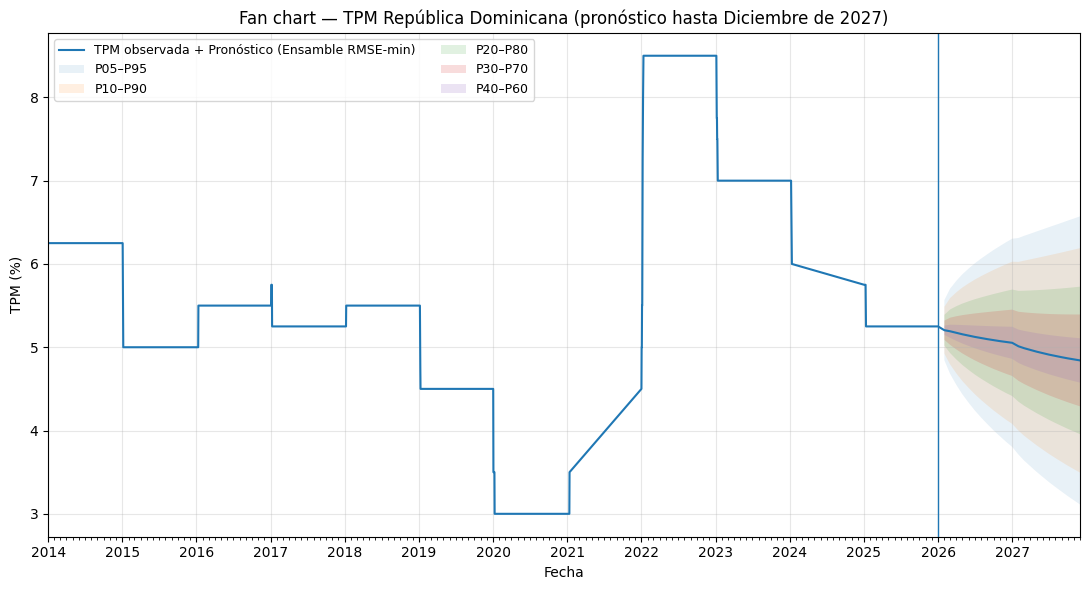

In [19]:
# =========================
# 6) Fan chart
# =========================
oos_ens = pred.loc[min_train:, ["actual","ensamble"]].dropna()
sigma1 = float(np.std((oos_ens["actual"]-oos_ens["ensamble"]).values, ddof=1))

nd = NormalDist()
bands = [(0.05,0.95,"P05–P95"),(0.10,0.90,"P10–P90"),(0.20,0.80,"P20–P80"),(0.30,0.70,"P30–P70"),(0.40,0.60,"P40–P60")]
sd_h = sigma1*np.sqrt(np.arange(1,h+1))

fig, ax = plt.subplots(figsize=(11,6))

# Filter historical data up to the last observed date
historical_data_for_plot = df[df['date'] <= last_obs_date][['date', 'tpm_rd']].copy()

# Combine historical data with the ensemble forecast
# Rename 'Ensamble_RMSEmin' to 'tpm_rd' to make concat easier
forecast_data_for_plot = fc_df[['date', 'Ensamble_RMSEmin']].rename(columns={'Ensamble_RMSEmin': 'tpm_rd'})

combined_plot_df = pd.concat([historical_data_for_plot, forecast_data_for_plot], ignore_index=True)

# Plot the combined observed + forecast line
ax.plot(combined_plot_df["date"], combined_plot_df["tpm_rd"], label="TPM observada + Pronóstico (Ensamble RMSE-min)")

# Plot the fan chart bands for the forecast period only
alphas = [0.10,0.12,0.14,0.16,0.18]
for (lo,hi,label),a in zip(bands, alphas):
    lo_s = ens_fc + nd.inv_cdf(lo)*sd_h
    hi_s = ens_fc + nd.inv_cdf(hi)*sd_h
    ax.fill_between(fc_dates, lo_s, hi_s, alpha=a, label=label)

ax.axvline(last_obs_date, linewidth=1)
ax.set_title("Fan chart — TPM República Dominicana (pronóstico hasta Diciembre de 2027)")
ax.set_xlabel("Fecha")
ax.set_ylabel("TPM (%)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", ncol=2, fontsize=9)

# Set x-axis limits to cover the entire date range
ax.set_xlim(combined_plot_df["date"].min(), combined_plot_df["date"].max())

# Set major ticks to show year, minor ticks to show month
import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

plt.tight_layout()
plt.show()

In [24]:
# 4) (Opcional) Tabla completa del período proyectado (exógenas + pronóstico)

#Esto te deja un “dataset de proyección” listo para revisión:

# Filter df_temp for the forecast period (where actual tpm_rd is NaN)
# df_temp now contains all original and extrapolated exogenous variables
projected_exog_data = df_temp[df_temp['date'] >= start_forecast_period].copy()

# Select the original exogenous variables plus 'date' for the projection table
# excluding the diffs, as they are calculated later and not primary inputs for the table
exog_cols_for_proj_table = ["date", "ipc_yoy","core_ipc_yoy","imae_yoy","fx","policy_us","oil","credit_yoy","m2_yoy","expect_inf_12m"]

# Create the base for the projection table with exogenous variables
proj_table_base = projected_exog_data[exog_cols_for_proj_table]

# Merge with the forecast results (fc_df contains SARIMAX, ARDL, Markov, Ensamble)
proj_table = pd.merge(proj_table_base, fc_df, on="date", how="left")
proj_table

,date,ipc_yoy,core_ipc_yoy,imae_yoy,fx,policy_us,oil,credit_yoy,m2_yoy,expect_inf_12m,SARIMAX,ARDL,Markov,Ensamble_RMSEmin,Ensamble_25pb
0,2026-02-01,4.90,4.89,3.47,63.51,3.64,66.6,8.32,9.72,4.07,5.217750,5.198956,5.244805,5.221171,5.25
1,2026-03-01,4.72,4.89,3.47,63.51,3.64,66.6,8.32,9.72,4.07,5.214765,5.141128,5.238045,5.196788,5.25
2,2026-04-01,4.55,4.89,3.47,63.51,3.64,66.6,8.32,9.72,4.07,5.216432,5.083369,5.230911,5.173482,5.25
3,2026-05-01,4.37,4.89,3.47,63.51,3.64,66.6,8.32,9.72,4.07,5.218293,5.025915,5.223755,5.150328,5.25
4,2026-06-01,4.20,4.89,3.47,63.51,3.64,66.6,8.32,9.72,4.07,5.219603,4.968501,5.216656,5.127069,5.25
5,2026-07-01,4.02,4.89,3.47,63.51,3.64,66.6,8.32,9.72,4.07,5.221115,4.911366,5.209612,5.103985,5.00
6,2026-08-01,3.84,4.89,3.47,63.51,3.64,66.6,8.32,9.72,4.07,5.222083,4.854247,5.202609,5.080782,5.00
7,2026-09-01,3.67,4.89,3.47,63.51,3.64,66.6,8.32,9.72,4.07,5.222886,4.797143,5.195631,5.057551,5.00
8,2026-10-01,3.49,4.89,3.47,63.51,3.64,66.6,8.32,9.72,4.07,5.223901,4.740294,5.188667,5.034474,5.00
9,2026-11-01,3.32,4.89,3.47,63.51,3.64,66.6,8.32,9.72,4.07,5.224383,4.683439,5.181713,5.011261,5.00
